Load all the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [2]:
import tensorflow.keras
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Input, Flatten, Rescaling, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import RMSprop, Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

Load Dataset

In [3]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

print("Training shape:", X_train.shape)
print("Testing shape :", X_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
Training shape: (50000, 32, 32, 3)
Testing shape : (10000, 32, 32, 3)


DEFINE IMAGE SIZE + BATCH SIZE

In [4]:
IMG_SIZE = 64
BATCH_SIZE = 32

ONE-HOT ENCODE LABELS

In [5]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

CREATE TENSORFLOW DATASETS

In [6]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train_cat)
)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test_cat)
)

DEFINE PREPROCESS FUNCTION

In [7]:
def preprocess(image, label):

    image = tf.image.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    image = preprocess_input(image)

    return image, label

APPLY PREPROCESSING PIPELINE

In [8]:
train_dataset = (
    train_dataset
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(10000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    test_dataset
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

LOAD PRE-TRAINED MOBILENETV2 MODEL

In [9]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

/tmp/ipykernel_2248/3920727893.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


FREEZE BASE MODEL

In [26]:
base_model.trainable = False

BUILD CUSTOM CLASSIFIER

In [10]:
model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(10, activation='softmax')

])

COMPILE MODEL

In [11]:
model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']

)

MODEL SUMMARY

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,106 (9.99 MB)

 Trainable params: 2,585,994 (9.86 MB)

 Non-trainable params: 34,112 (133.25 KB)

DEFINE CALLBACKS

In [13]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

PLOTTING THE MODELS

TRAIN MODEL

In [14]:
history = model.fit(

    train_dataset,

    validation_data=test_dataset,

    epochs=30,

    callbacks=[
        early_stop,
        reduce_lr
    ]

)

Epoch 1/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 129s 44ms/step - accuracy: 0.6241 - loss: 1.1905 - val_accuracy: 0.3727 - val_loss: 2.4010 - learning_rate: 0.0010
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 20ms/step - accuracy: 0.6985 - loss: 0.9382 - val_accuracy: 0.5367 - val_loss: 1.5908 - learning_rate: 0.0010
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 21ms/step - accuracy: 0.7395 - loss: 0.8198 - val_accuracy: 0.1512 - val_loss: 3.2612 - learning_rate: 0.0010
Epoch 4/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 20ms/step - accuracy: 0.7386 - loss: 0.8063 - val_accuracy: 0.2518 - val_loss: 3.5429 - learning_rate: 0.0010
Epoch 5/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 20ms/step - accuracy: 0.7563 - loss: 0.7466 - val_accuracy: 0.2433 - val_loss: 2.7356 - learning_rate: 0.0010
Epoch 6/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 20ms/step - accuracy: 0.7672 - loss: 0.6993 - val_accuracy: 0.8023 - val_loss: 0.5967 - learning_rate: 2.0000e-04
Epoch 7/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 21ms/step - a

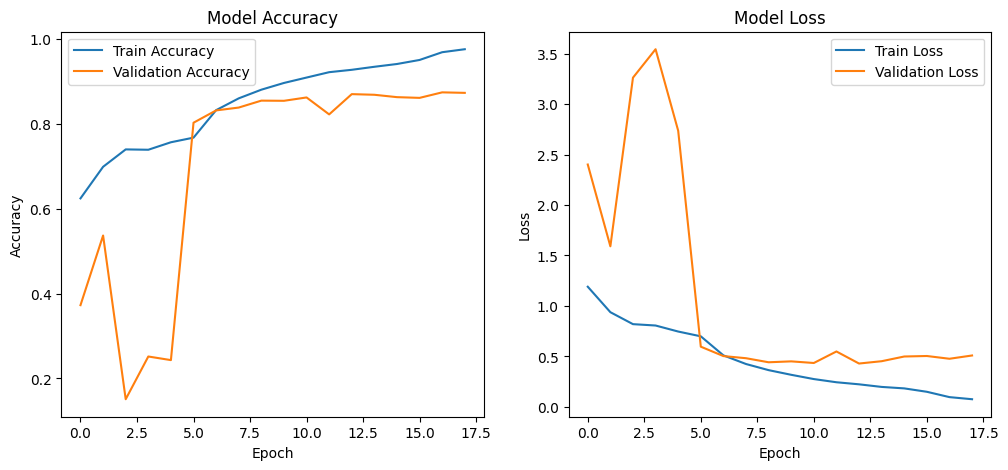

In [15]:
import matplotlib.pylab as plt
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


EVALUATE MODEL

In [16]:
test_loss, test_accuracy = model.evaluate(
    test_dataset
)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8696 - loss: 0.4298
Test Accuracy: 0.8695999979972839


MAKE PREDICTIONS

In [17]:
y_pred_probs = model.predict(test_dataset)

y_pred = np.argmax(y_pred_probs, axis=1)

y_true = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step


CLASSIFICATION REPORT

In [18]:
print(

    classification_report(

        y_true,
        y_pred,

        target_names=class_names

    )

)

              precision    recall  f1-score   support

    airplane       0.89      0.86      0.88      1000
  automobile       0.95      0.92      0.94      1000
        bird       0.88      0.76      0.82      1000
         cat       0.77      0.72      0.74      1000
        deer       0.83      0.90      0.86      1000
         dog       0.78      0.83      0.81      1000
        frog       0.90      0.89      0.90      1000
       horse       0.90      0.90      0.90      1000
        ship       0.91      0.95      0.93      1000
       truck       0.88      0.96      0.92      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



CONFUSION MATRIX

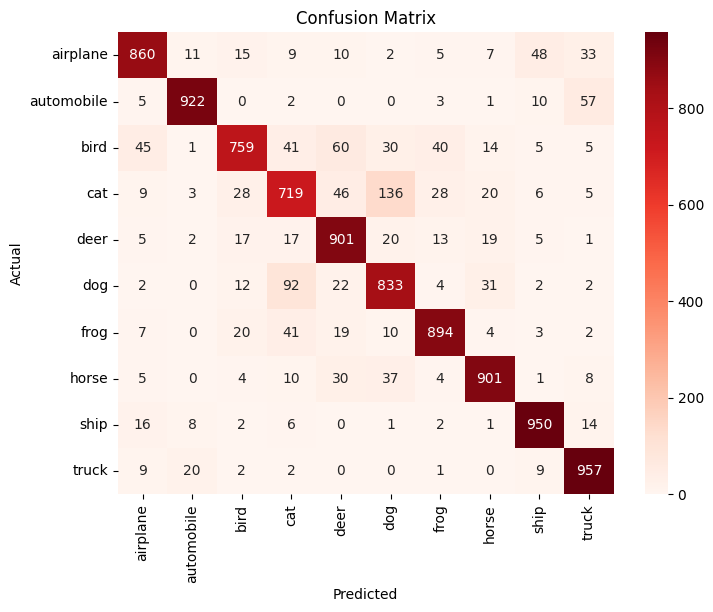

In [19]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

UNFREEZE LAYERS + FINE-TUNING

In [20]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

RECOMPILE WITH LOW LEARNING RATE

In [21]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss='categorical_crossentropy',

    metrics=['accuracy']

)

MODEL SUMMARY

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,106 (9.99 MB)

 Trainable params: 1,888,522 (7.20 MB)

 Non-trainable params: 731,584 (2.79 MB)

FINE-TUNE TRAINING

In [23]:
fine_tune_history = model.fit(

    train_dataset,

    validation_data=test_dataset,

    epochs=30,

    callbacks=[
        early_stop,
        reduce_lr
    ]

)

Epoch 1/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 50s 21ms/step - accuracy: 0.9567 - loss: 0.1376 - val_accuracy: 0.8768 - val_loss: 0.4280 - learning_rate: 1.0000e-05
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.9579 - loss: 0.1298 - val_accuracy: 0.8779 - val_loss: 0.4389 - learning_rate: 1.0000e-05
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9581 - loss: 0.1272 - val_accuracy: 0.8778 - val_loss: 0.4465 - learning_rate: 1.0000e-05
Epoch 4/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9582 - loss: 0.1269 - val_accuracy: 0.8764 - val_loss: 0.4518 - learning_rate: 1.0000e-05
Epoch 5/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9590 - loss: 0.1249 - val_accuracy: 0.8770 - val_loss: 0.4531 - learning_rate: 2.0000e-06
Epoch 6/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9597 - loss: 0.1248 - val_accuracy: 0.8768 - val_loss: 0.4537 - learning_rate: 2.0000e-06


PLOTTING THE MODELS

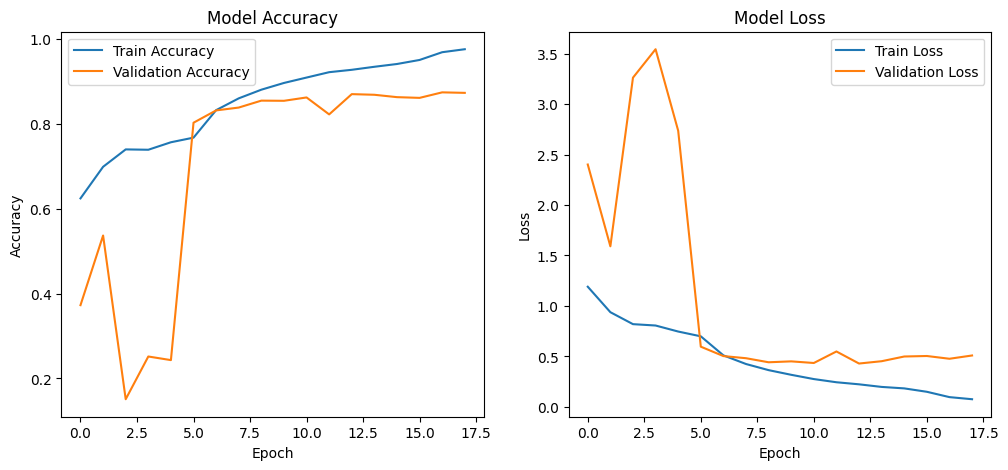

In [24]:
import matplotlib.pylab as plt
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

FINAL EVALUATION:

Final Prediction

In [25]:
final_predictions = model.predict(test_dataset)

y_pred_final = np.argmax(
    final_predictions,
    axis=1
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step


Final Classification report

In [26]:
print(

    classification_report(

        y_true,
        y_pred_final,

        target_names=class_names

    )

)

              precision    recall  f1-score   support

    airplane       0.88      0.90      0.89      1000
  automobile       0.95      0.94      0.94      1000
        bird       0.87      0.80      0.83      1000
         cat       0.76      0.73      0.75      1000
        deer       0.86      0.89      0.87      1000
         dog       0.80      0.82      0.81      1000
        frog       0.89      0.91      0.90      1000
       horse       0.90      0.90      0.90      1000
        ship       0.93      0.94      0.93      1000
       truck       0.92      0.94      0.93      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



Final Confusion Matrix

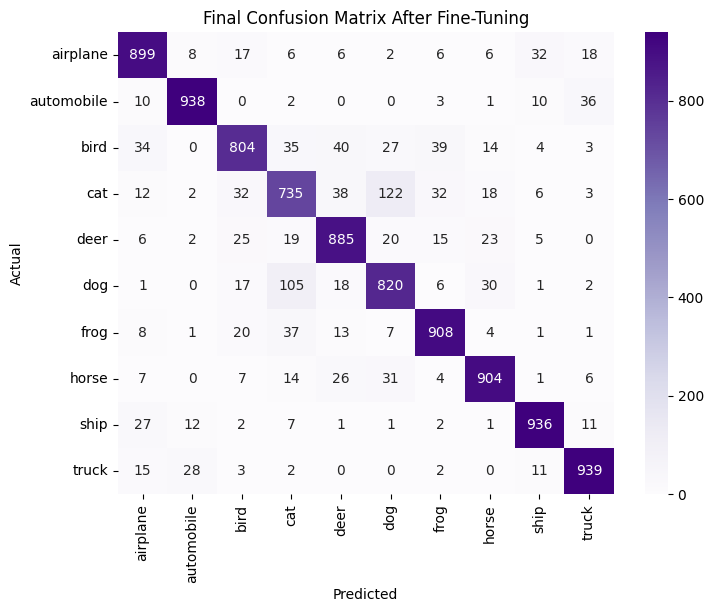

In [27]:
cm_final = confusion_matrix(
    y_true,
    y_pred_final
)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm_final,

    annot=True,
    fmt='d',

    cmap='Purples',

    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Final Confusion Matrix After Fine-Tuning"
)

plt.show()

CONCLUSION:

* Validation accuracy stability

* Reduced the train/validation gap

* Smoother convergence

* Lower validation loss initially

SAVING THE BEST MODEL

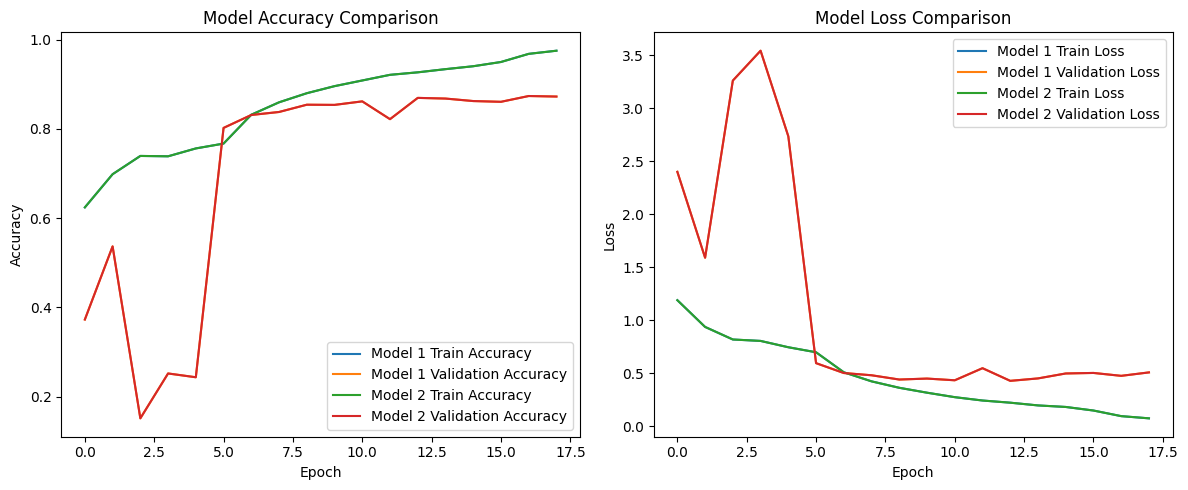

In [31]:

# COMPARE TWO MODEL HISTORIES
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# ACCURACY COMPARISON

plt.subplot(1,2,1)

# Model 1
plt.plot(

    history.history['accuracy'],

    label='Model 1 Train Accuracy'
)

plt.plot(

    history.history['val_accuracy'],

    label='Model 1 Validation Accuracy'
)

# Model 2
plt.plot(

    history.history['accuracy'],

    label='Model 2 Train Accuracy'
)

plt.plot(

    history.history['val_accuracy'],

    label='Model 2 Validation Accuracy'
)

plt.title("Model Accuracy Comparison")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()


# LOSS COMPARISON


plt.subplot(1,2,2)

# Model 1
plt.plot(

    history.history['loss'],

    label='Model 1 Train Loss'
)

plt.plot(

    history.history['val_loss'],

    label='Model 1 Validation Loss'
)

# Model 2
plt.plot(

    history.history['loss'],

    label='Model 2 Train Loss'
)

plt.plot(

    history.history['val_loss'],

    label='Model 2 Validation Loss'
)

plt.title("Model Loss Comparison")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.tight_layout()

plt.show()

In [32]:
model.save(
    "mobilenet_cifar10.keras"
)